In [40]:
!pip install mediapipe -q

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np
import tensorflow as tf
import sqlite3

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [8]:
import zipfile
import os

zip_filename = "archive (1).zip"

print(f"Unzipping: {zip_filename}")

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("psl_dataset")

print("Dataset unzipped successfully!")

# Show folder structure
print("\nContents of psl_dataset folder:")
print(os.listdir("psl_dataset"))

print("\nContents inside PSL_dataset:")
print(os.listdir("psl_dataset/PSL_dataset"))

Unzipping: archive (1).zip
Dataset unzipped successfully!

Contents of psl_dataset folder:
['main_dataset.db', 'PSL_dataset']

Contents inside PSL_dataset:
['datasets', 'main_dataset.db']


In [12]:
db_path = "psl_dataset/main_dataset.db"

conn = sqlite3.connect(db_path)


tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("✅ Available tables in the database:")
print(tables['name'].tolist())

# Try loading the alphabet data with correct table name
print("\nTrying to load alphabet data...")

try:
    df = pd.read_sql("SELECT * FROM rightHandDataset", conn)
    print("\n✅ Loaded rightHandDataset successfully!")
except Exception as e:
    print("Error with rightHandDataset:", str(e))
    # Try alternative table name if it exists
    if 'poseDataset' in tables['name'].tolist():
        print("Trying poseDataset instead...")
        df = pd.read_sql("SELECT * FROM poseDataset", conn)
        print("Loaded poseDataset")

print("\nDataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nNumber of unique signs:", df['label'].nunique())
print("\nSamples per sign:")
print(df['label'].value_counts().sort_index())

✅ Available tables in the database:
['rightHandDataset', 'poseDataset', 'wordDataset']

Trying to load alphabet data...

✅ Loaded rightHandDataset successfully!

Dataset shape: (5112, 44)
Columns: ['id', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6', 'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12', 'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'x17', 'y17', 'x18', 'y18', 'x19', 'y19', 'x20', 'y20', 'x21', 'y21', 'label']

Number of unique signs: 37

Samples per sign:
label
ء‬     87
ا     246
ب     177
ت‬    216
ث‬     99
ج‬    156
ح‬    117
خ‬    216
د‬    159
ذ‬    111
ر‬    162
ز‬     84
س‬    195
ش‬    114
ص‬     84
ض‬     45
ط‬     84
ظ‬     30
ع‬    102
غ‬     48
ف‬     39
ق‬    279
ل‬     63
م‬    252
ن‬     57
و‬    411
ٹ‬    162
پ     144
چ‬    153
ڈ‬    141
ڑ‬     51
ژ‬     87
ک‬     33
گ‬     81
ہ‬    120
ی‬    279
ے‬    228
Name: count, dtype: int64


/tmp/ipykernel_9666/2534024472.py:9: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9666/2534024472.py:9: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_9666/2534024472.py:9: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

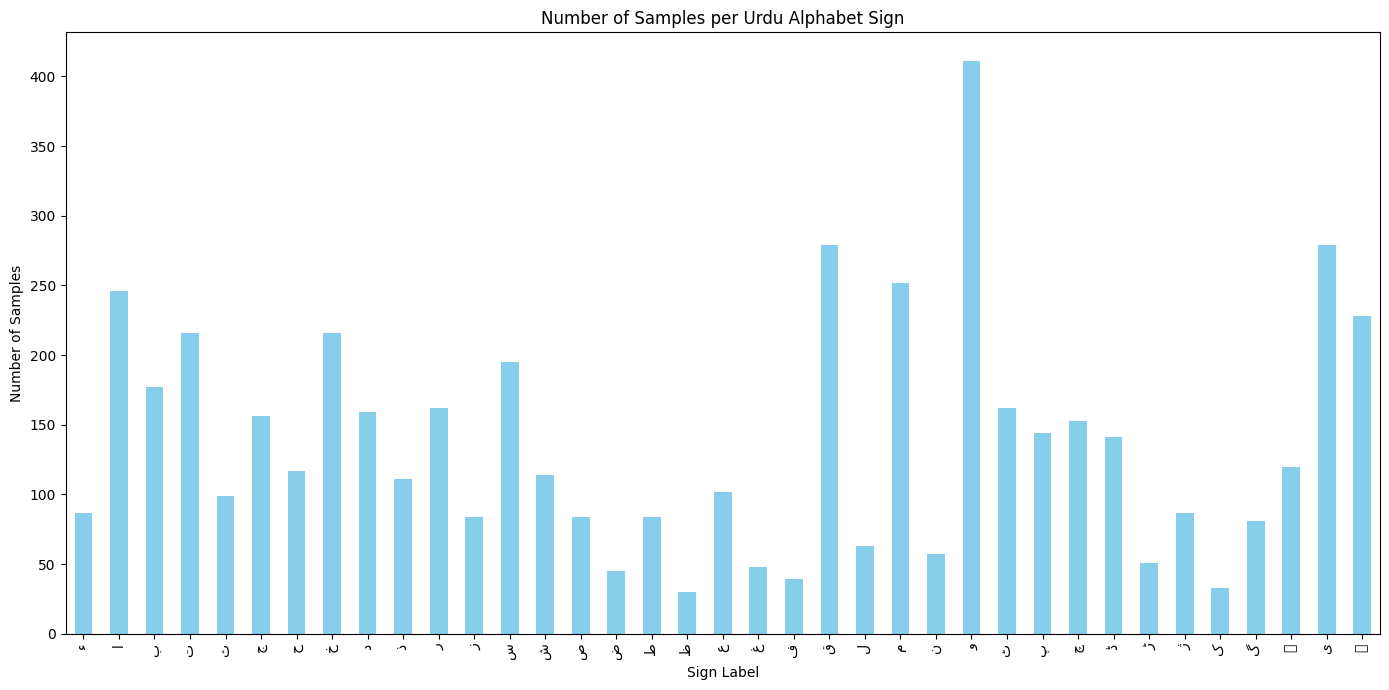

In [13]:
plt.figure(figsize=(14, 7))
df['label'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Number of Samples per Urdu Alphabet Sign")
plt.xlabel("Sign Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9666/1118403489.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, palette="Blues_d")
/tmp/ipykernel_9666/1118403489.py:11: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9666/1118403489.py:11: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_9666/1118403489.py:11: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarn

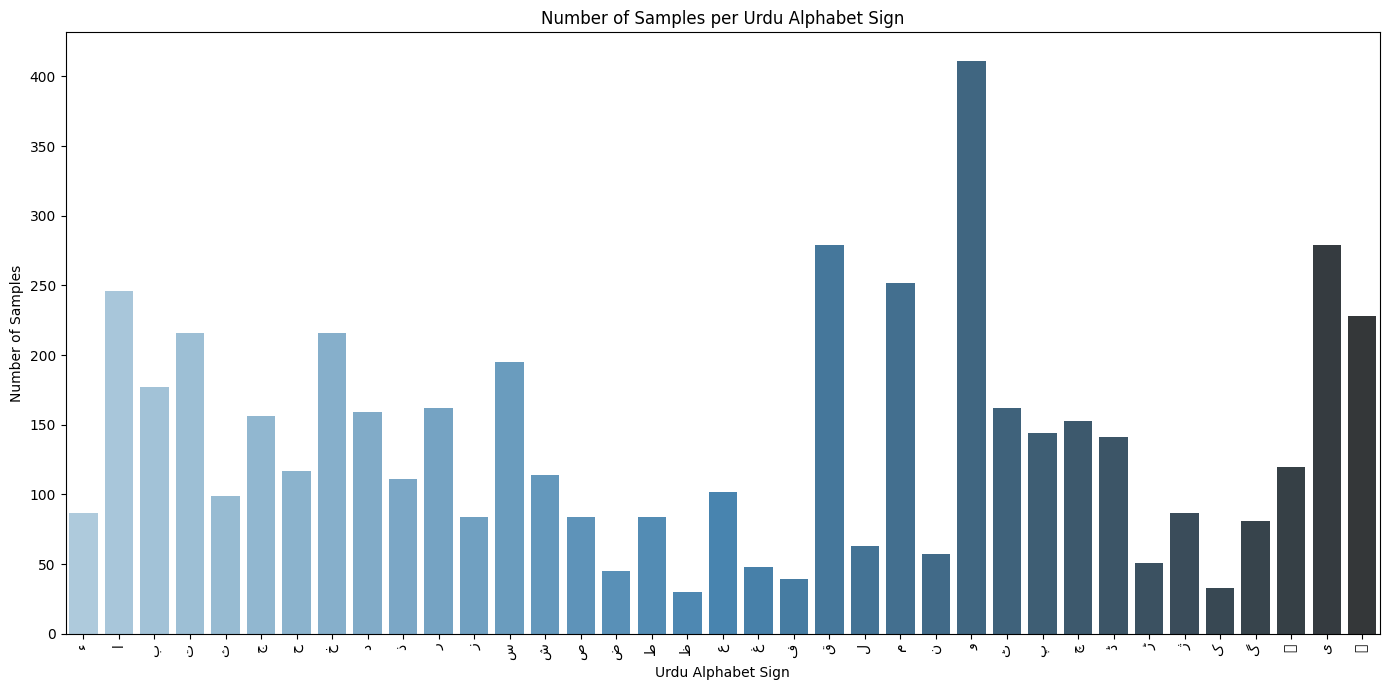

Most common sign: و‬ with 411 samples
Least common sign: ظ‬ with 30 samples


In [16]:
plt.figure(figsize=(14, 7))
value_counts = df['label'].value_counts().sort_index()
sns.barplot(x=value_counts.index, y=value_counts.values, palette="Blues_d")
plt.title("Number of Samples per Urdu Alphabet Sign")
plt.xlabel("Urdu Alphabet Sign")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Most common sign:", value_counts.idxmax(), "with", value_counts.max(), "samples")
print("Least common sign:", value_counts.idxmin(), "with", value_counts.min(), "samples")

In [19]:
# Convert string labels (Urdu) to integer numbers
label_to_id = {label: idx for idx, label in enumerate(class_names)}
y_numeric = np.array([label_to_id[label] for label in y])

In [20]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y_numeric,
                                                  test_size=0.2,
                                                  random_state=42,
                                                  stratify=y_numeric)

In [21]:
# Convert to one-hot encoding
num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)

In [22]:
# Build simple model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model summary:")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,165 (63.14 KB)

 Trainable params: 16,165 (63.14 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Train the model
history = model.fit(X_train, y_train_cat,
                    validation_data=(X_val, y_val_cat),
                    epochs=15,
                    batch_size=32,
                    verbose=1)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0861 - loss: 24.4580 - val_accuracy: 0.1457 - val_loss: 3.3301
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1350 - loss: 3.6824 - val_accuracy: 0.1779 - val_loss: 3.1893
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2035 - loss: 3.2325 - val_accuracy: 0.2747 - val_loss: 2.8230
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2494 - loss: 2.8602 - val_accuracy: 0.3011 - val_loss: 2.4571
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3527 - loss: 2.3283 - val_accuracy: 0.5357 - val_loss: 1.6977
Epoch 6/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4930 - loss: 1.7060 - val_accuracy: 0.7331 - val_loss: 0.9879
Epoch 7/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6341 - loss: 1.2026 - val_accuracy: 0.8094 - val_loss: 0.6681
Epoch 8/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7366 - loss: 0.8439 - val_accuracy: 0

In [39]:
val_loss, val_accuracy = model.evaluate(X_val, y_val_cat, verbose=0)
print("=== Final Model Performance ===")
print(f"Validation Accuracy: {val_accuracy}")
print(f"Validation Loss: {val_loss}")



=== Final Model Performance ===
Validation Accuracy: 0.9706745147705078
Validation Loss: 0.11702918261289597


In [37]:
model.save("psl_alphabet_model.h5")
print("\n✅ Model trained and saved as psl_alphabet_model.h5")


✅ Model trained and saved as psl_alphabet_model.h5


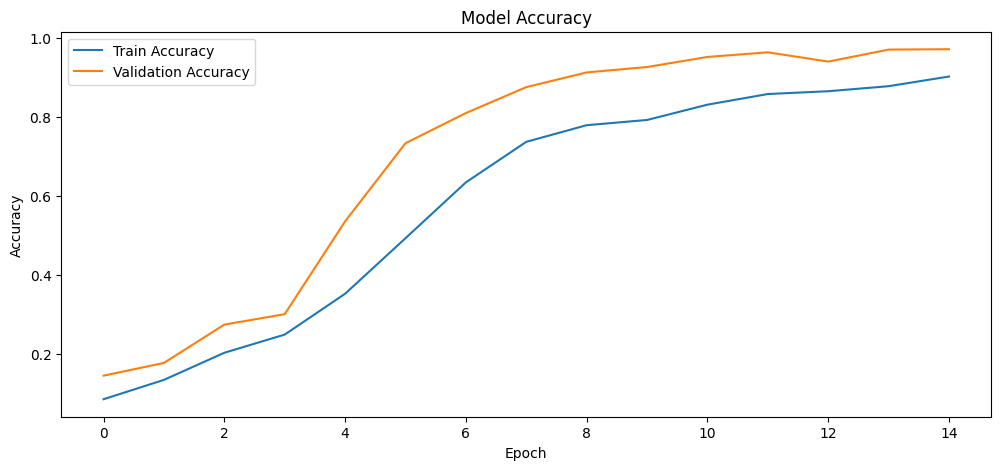

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

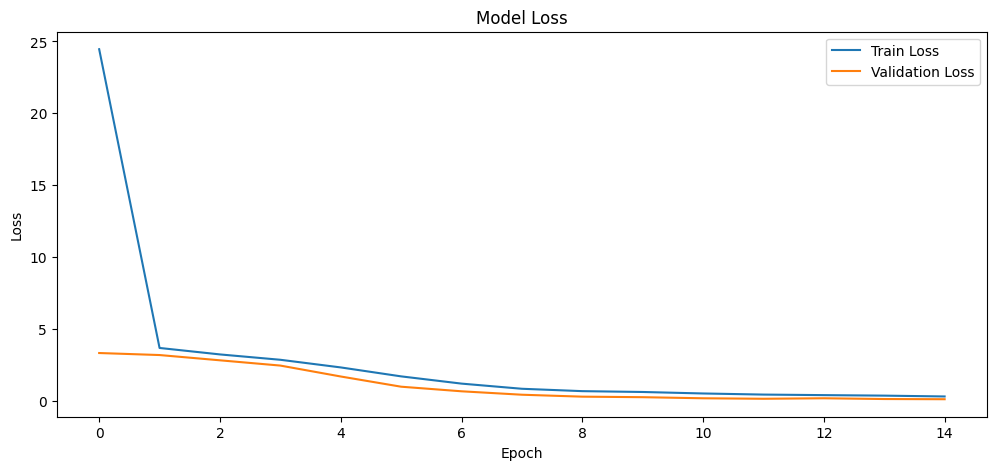

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()